# CRISP-DM Framework

## Loan Default Prediction_Enhancing Credit Risk Modeling with ML and AI

## 1. Business Understanding:

Predicting loan defaults is a critical challenge for banks and financial institutions, as it directly impacts profitability, risk management, and the ability to offer future credit. When too many borrowers fail to repay their loans, lenders face financial losses, reduced liquidity, and increased lending restrictions. These defaults can also damage investor confidence and weaken customer trust.

**Goal**

To mitigate this risk, lenders analyze historical borrower data—such as income, credit score, loan purpose, and repayment history—to uncover patterns. This project leverages that data to develop a machine learning model that can classify borrowers as either:
* Low Risk Borrower
* Medium Risk Borrower
* High Risk Borrower

The model will learn from past loan outcomes and borrower profiles to predict default risk with high accuracy.

Analyze borrowers displaying irregular income, spending, or credit behavior that may suggest fraud. Calculate the probability of default for each applicant and assess model performance using the AUC score to ensure accurate classification, enabling early detection of high-risk or potentially fraudulent loan applications.

Also, identify and examine borrowers who exhibit unusual income levels, spending habits, or credit usage patterns that could signal potential loan fraud or misrepresentation. These anomalies may highlight high-risk profiles that require further scrutiny before loan approval to ensure responsible lending and prevent fraudulent activity.

**Business Benefit:**

By incorporating this classification approach, financial institutions can make more informed lending decisions. High-risk applicants can be flagged for further scrutiny or offered adjusted loan terms, while low-risk borrowers may benefit from faster approvals and more favorable rates. 

Ultimately, this data-driven approach enhances operational efficiency, reduces financial losses, and supports fairer, more inclusive lending practices. It empowers institutions to move beyond guesstimates and more toward consistent, evidence-based decision-making. In doing so, it creates a win-win scenario: banks protect their assets, and reliable borrowers gain better access to credit.

**Key Questions to Answer**

What are the most important factors that influence loan default?

Can we accurately identify high-risk borrowers before loan approval?

How do machine learning models compare in predicting default risk (e.g., logistic regression vs. XGBoost vs. neural network)?

How can predictions be communicated in a way that’s useful for business stakeholders?


**Success Criteria:**

Technical: Achieve a model performance with AUC ≥ 0.85, high precision for the “default” class, and low false positives.

Business: Deliver actionable insights and risk indicators that help non-technical stakeholders make informed lending decisions.

Ethical: Ensure the model avoids biased decisions that disproportionately affect certain groups (e.g., through careful feature selection and fairness evaluation).


## 2. Data Understanding

In [26]:
# Core Libraries
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import plotly.express as px
from IPython.display import display

# Jupyter-specific (only include if running in Jupyter)
%matplotlib inline

# Ignore warnings
warnings.filterwarnings('ignore')

# Scikit-learn Configuration
from sklearn import set_config

# Feature Engineering and Decomposition
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectFromModel, SequentialFeatureSelector
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, LabelEncoder

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import (
    VotingClassifier, RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, mean_absolute_error, mean_squared_error,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

# Model Selection
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline

# Model Inspection
from sklearn.inspection import permutation_importance

# Imbalanced Data Handling
from imblearn.over_sampling import SMOTE

# TensorFlow
import tensorflow as tf



In [27]:
data = pd.read_csv('loans_full_schema.csv')

In [28]:
data.head(10)

,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,...,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,NaN,...,C3,Mar-2018,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,NaN,...,C1,Feb-2018,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,NaN,...,D1,Feb-2018,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,NaN,...,A3,Jan-2018,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,37.66,...,C3,Mar-2018,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0
5,NaN,NaN,KY,OWN,34000.0,Not Verified,6.46,NaN,NaN,NaN,...,A3,Jan-2018,Current,whole,Cash,4256.71,873.13,743.29,129.84,0.0
6,hr,10.0,MI,MORTGAGE,35000.0,Source Verified,23.66,155000.0,Not Verified,13.12,...,C2,Jan-2018,Current,whole,Cash,22560.00,2730.51,1440.00,1290.51,0.0
7,police,10.0,AZ,MORTGAGE,110000.0,Source Verified,16.19,NaN,NaN,NaN,...,B5,Jan-2018,Current,whole,Cash,19005.39,1765.84,994.61,771.23,0.0
8,parts,10.0,NV,MORTGAGE,65000.0,Source Verified,36.48,NaN,NaN,NaN,...,C2,Feb-2018,Current,whole,Cash,18156.66,2703.22,1843.34,859.88,0.0
9,4th person,3.0,IL,RENT,30000.0,Not Verified,18.91,NaN,NaN,NaN,...,A3,Mar-2018,Current,fractional,Cash,6077.13,391.15,322.87,68.28,0.0


In [29]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 55 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   emp_title                         9167 non-null   object 
 1   emp_length                        9183 non-null   float64
 2   state                             10000 non-null  object 
 3   homeownership                     10000 non-null  object 
 4   annual_income                     10000 non-null  float64
 5   verified_income                   10000 non-null  object 
 6   debt_to_income                    9976 non-null   float64
 7   annual_income_joint               1495 non-null   float64
 8   verification_income_joint         1455 non-null   object 
 9   debt_to_income_joint              1495 non-null   float64
 10  delinq_2y                         10000 non-null  int64  
 11  months_since_last_delinq          4342 non-null   float64
 12  earli

,emp_length,annual_income,debt_to_income,annual_income_joint,debt_to_income_joint,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,total_credit_lines,...,public_record_bankrupt,loan_amount,term,interest_rate,installment,balance,paid_total,paid_principal,paid_interest,paid_late_fees
count,9183.000000,1.000000e+04,9976.000000,1.495000e+03,1495.000000,10000.00000,4342.000000,10000.00000,10000.00000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.930306,7.922215e+04,19.308192,1.279146e+05,19.979304,0.21600,36.760709,2001.29000,1.95820,22.679600,...,0.123800,16361.922500,43.272000,12.427524,476.205323,14458.916610,2494.234773,1894.448466,599.666781,0.119516
std,3.703734,6.473429e+04,15.004851,7.016838e+04,8.054781,0.68366,21.634939,7.79551,2.38013,11.885439,...,0.337172,10301.956759,11.029877,5.001105,294.851627,9964.561865,3958.230365,3884.407175,517.328062,1.813468
min,0.000000,0.000000e+00,0.000000,1.920000e+04,0.320000,0.00000,1.000000,1963.00000,0.00000,2.000000,...,0.000000,1000.000000,36.000000,5.310000,30.750000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,4.500000e+04,11.057500,8.683350e+04,14.160000,0.00000,19.000000,1997.00000,0.00000,14.000000,...,0.000000,8000.000000,36.000000,9.430000,256.040000,6679.065000,928.700000,587.100000,221.757500,0.000000
50%,6.000000,6.500000e+04,17.570000,1.130000e+05,19.720000,0.00000,34.000000,2003.00000,1.00000,21.000000,...,0.000000,14500.000000,36.000000,11.980000,398.420000,12379.495000,1563.300000,984.990000,446.140000,0.000000
75%,10.000000,9.500000e+04,25.002500,1.515455e+05,25.500000,0.00000,53.000000,2006.00000,3.00000,29.000000,...,0.000000,24000.000000,60.000000,15.050000,644.690000,20690.182500,2616.005000,1694.555000,825.420000,0.000000
max,10.000000,2.300000e+06,469.090000,1.100000e+06,39.980000,13.00000,118.000000,2015.00000,29.00000,87.000000,...,3.000000,40000.000000,60.000000,30.940000,1566.590000,40000.000000,41630.443684,40000.000000,4216.440000,52.980000


In [30]:
def describe_columns(df):
    desc = pd.DataFrame({
        'Null Count': df.isnull().sum(),
        'Non-Null Count': df.notnull().sum(),
        '% Null': round(df.isnull().mean() * 100, 2),
        'Unique Values': df.nunique(),
    })

    # Numeric-only columns
    numeric_cols = df.select_dtypes(include='number').columns

    # Get raw min/max for numeric columns
    min_vals = df[numeric_cols].min()
    max_vals = df[numeric_cols].max()

    # Format min/max values 
    desc['Min'] = min_vals.apply(lambda x: f"{x:,.0f}")
    desc['Max'] = max_vals.apply(lambda x: f"{x:,.0f}")

    # Format Quartiles
    quartiles = df[numeric_cols].quantile([0.25, 0.5, 0.75]).T
    quartiles.columns = ['25%', '50%', '75%']
    quartiles = quartiles.applymap(lambda x: f"{x:,.0f}")

    # Join quartiles and sort
    return desc.join(quartiles, how='left').sort_values(by='% Null', ascending=False)

#Call Function
describe_columns(data)

,Null Count,Non-Null Count,% Null,Unique Values,Min,Max,25%,50%,75%
verification_income_joint,8545,1455,85.45,3,NaN,NaN,NaN,NaN,NaN
debt_to_income_joint,8505,1495,85.05,1189,0,40,14,20,26
annual_income_joint,8505,1495,85.05,596,"19,200","1,100,000","86,834","113,000","151,546"
months_since_90d_late,7715,2285,77.15,106,2,128,29,47,63
months_since_last_delinq,5658,4342,56.58,97,1,118,19,34,53
months_since_last_credit_inquiry,1271,8729,12.71,25,0,24,2,6,11
emp_title,833,9167,8.33,4741,NaN,NaN,NaN,NaN,NaN
emp_length,817,9183,8.17,11,0,10,2,6,10
num_accounts_120d_past_due,318,9682,3.18,1,0,0,0,0,0
debt_to_income,24,9976,0.24,3673,0,469,11,18,25


## 3.Data Prepration

### Feature Engineering

In [33]:
# Engineer things like: installment_to_income, credit_utilization_rate, credit_history_length

def engineer_loan_features(data, current_year=2018):
    """
    Engineer additional features for loan risk prediction.
    
    Parameters:
        data (pd.DataFrame): Input DataFrame with raw loan data.
        current_year (int): Reference year to compute credit history length.
    
    Returns:
        pd.DataFrame: DataFrame with engineered features and risk_category.
    """
    # Copy to avoid modifying original
    data_fe = data.copy()
    
    # Installment-to-income ratio
    data_fe['installment_to_income'] = data_fe['installment'] / (data_fe['annual_income'] + 1)
    
    # Credit utilization rate
    data_fe['credit_utilization_rate'] = data_fe['total_credit_utilized'] / (data_fe['total_credit_limit'] + 1)
    
    # Credit history length
    data_fe['credit_history_length'] = current_year - data_fe['earliest_credit_line']
    
    # High utilization flag
    data_fe['high_utilization_flag'] = (data_fe['credit_utilization_rate'] > 0.8).astype(int)
    
    # Verified income flag
    data_fe['verified_income_flag'] = data_fe['verified_income'].apply(lambda x: 1 if x == 'Verified' else 0)
    
    # Delinquency ratio
    data_fe['delinq_ratio'] = data_fe['delinq_2y'] / (data_fe['total_credit_lines'] + 1)
    
    # Balance to loan ratio
    data_fe['balance_to_loan_ratio'] = data_fe['balance'] / (data_fe['loan_amount'] + 1)
    
    # Paid percentage of principal
    data_fe['paid_pct'] = data_fe['paid_principal'] / (data_fe['loan_amount'] + 1)
    
    # Risk category mapping
    def map_risk(status):
        if status in ['Fully Paid', 'Current']:
            return 'Low'
        elif status in ['In Grace Period', 'Late (16-30 days)']:
            return 'Medium'
        elif status in ['Late (31-120 days)', 'Charged Off']:
            return 'High'
        else:
            return 'Unknown'
    
    data_fe['risk_category'] = data_fe['loan_status'].apply(map_risk)
    
    return data_fe

# Engineer features 
data_with_features = engineer_loan_features(data)

# Preview
data_with_features.head()

,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,...,paid_late_fees,installment_to_income,credit_utilization_rate,credit_history_length,high_utilization_flag,verified_income_flag,delinq_ratio,balance_to_loan_ratio,paid_pct,risk_category
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,NaN,...,0.0,0.007250,0.547587,17,0,1,0.0,0.964818,0.035147,Low
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,NaN,...,0.0,0.004188,0.150030,22,0,0,0.0,0.930088,0.069712,Low
2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,NaN,...,0.0,0.001785,0.661321,12,0,0,0.0,0.911859,0.087641,Low
3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,NaN,...,0.0,0.022139,0.196725,11,0,0,0.0,0.872796,0.127158,Low
4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,37.66,...,0.0,0.022481,0.754897,10,0,1,0.0,0.931705,0.068251,Low


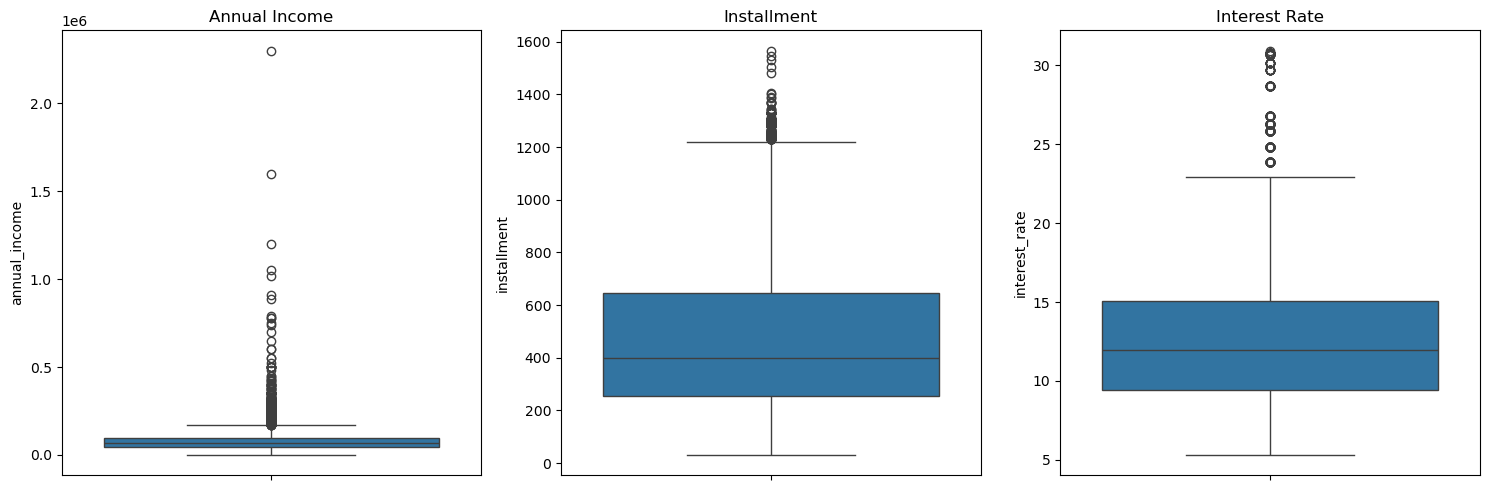

In [38]:
#find Outliers

plt.figure(figsize=(15, 5))

# Annual income
plt.subplot(1, 3, 1)
sns.boxplot(y=data_with_features['annual_income'])
plt.title('Annual Income')

# Installment
plt.subplot(1, 3, 2)
sns.boxplot(y=data_with_features['installment'])
plt.title('Installment')

# Interest rate
plt.subplot(1, 3, 3)
sns.boxplot(y=data_with_features['interest_rate'])
plt.title('Interest Rate')

plt.tight_layout()
plt.show()

In [42]:
#Function to clean the loan dataset

def clean_data(data):
    # Step 1: Drop columns with large % of nulls
    data = data.drop(columns=[
        'verification_income_joint', 
        'debt_to_income_joint', 
        'annual_income_joint'
    ])

    # Step 2: Impute remaining columns with -1
    data['months_since_90d_late'] = data['months_since_90d_late'].fillna(-1)
    data['months_since_last_delinq'] = data['months_since_last_delinq'].fillna(-1)

    # Step 3: Replace nulls with 'NA' for object columns
    object_features = ['emp_title']
    data[object_features] = data[object_features].fillna("NA")

    # Step 4: Replace nulls with most frequent values for selected float columns

    # Calculate the mode
    mode_value = data['emp_length'].mode(dropna=True)[0]
    mode_value = data['debt_to_income'].mode(dropna=True)[0]
    mode_value = data['months_since_last_credit_inquiry'].mode(dropna=True)[0]
    mode_value = data['num_accounts_120d_past_due'].mode(dropna=True)[0]

    # Replace NaNs with the mode
    data['emp_length'] = data['emp_length'].fillna(mode_value)
    data['debt_to_income'] = data['debt_to_income'].fillna(mode_value)
    data['months_since_last_credit_inquiry'] = data['months_since_last_credit_inquiry'].fillna(mode_value)
    data['num_accounts_120d_past_due'] = data['num_accounts_120d_past_due'].fillna(mode_value)

    # Step 5: Clean Emp_title
    
    # Step 5.1: Standardize formatting (lowercase, strip whitespace)
    data['emp_title_clean'] = data['emp_title'].str.lower().str.strip()

    # Step 5.2: Get the top 20 most common titles
    top_titles = data['emp_title_clean'].value_counts().nlargest(20).index

    # Step 5.3: Label rare titles as 'other'
    data['emp_title_clean'] = data['emp_title_clean'].apply(
        lambda x: x if x in top_titles else 'other'
    )

    # Step 5.4: convert to category
    data['emp_title_clean'] = data['emp_title_clean'].astype('category')

    # Step 5.5: Drop the original 'emp_title' column depending on your use case
    data.drop(columns='emp_title', inplace=True)

    # Step 5.6: Check result
    print(data['emp_title_clean'].value_counts())

    # Step 6: Remove Outliers
    data['log_annual_income'] = np.log1p(data['annual_income'])

    # Apply log(1 + x) transformation
    data['log_installment'] = np.log1p(data['installment'])
    data['log_interest_rate'] = np.log1p(data['interest_rate'])

    return data 

# Usage
data_cleaned = clean_data(data_with_features)

data_cleaned.head()

emp_title_clean
other                 7391
na                     833
manager                239
owner                  233
teacher                216
driver                 133
sales                  108
registered nurse       103
supervisor             102
rn                      81
truck driver            73
office manager          64
president               58
project manager         58
general manager         54
director                52
engineer                48
operations manager      45
mechanic                38
technician              36
sales manager           35
Name: count, dtype: int64


,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,...,high_utilization_flag,verified_income_flag,delinq_ratio,balance_to_loan_ratio,paid_pct,risk_category,emp_title_clean,log_annual_income,log_installment,log_interest_rate
0,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,0,38.0,2001,6,...,0,1,0.0,0.964818,0.035147,Low,other,11.407576,6.482388,2.712706
1,10.0,HI,RENT,40000.0,Not Verified,5.04,0,-1.0,1996,1,...,0,0,0.0,0.930088,0.069712,Low,other,10.596660,5.127173,2.610805
2,3.0,WI,RENT,40000.0,Source Verified,21.15,0,28.0,2006,4,...,0,0,0.0,0.911859,0.087641,Low,other,10.596660,4.282206,2.895359
3,1.0,PA,RENT,30000.0,Not Verified,10.16,0,-1.0,2007,0,...,0,0,0.0,0.872796,0.127158,Low,other,10.308986,6.500073,2.043814
4,10.0,CA,RENT,35000.0,Verified,57.96,0,-1.0,2008,7,...,0,1,0.0,0.931705,0.068251,Low,other,10.463132,6.669333,2.712706


In [44]:
describe_columns(data_cleaned)

,Null Count,Non-Null Count,% Null,Unique Values,Min,Max,25%,50%,75%
emp_length,0,10000,0.0,11,0,10,2,5,10
state,0,10000,0.0,50,NaN,NaN,NaN,NaN,NaN
loan_purpose,0,10000,0.0,12,NaN,NaN,NaN,NaN,NaN
application_type,0,10000,0.0,2,NaN,NaN,NaN,NaN,NaN
loan_amount,0,10000,0.0,612,"1,000","40,000","8,000","14,500","24,000"
...,...,...,...,...,...,...,...,...,...
total_debit_limit,0,10000,0.0,1222,0,"386,700","10,000","19,500","36,100"
num_total_cc_accounts,0,10000,0.0,56,2,66,7,11,17
num_open_cc_accounts,0,10000,0.0,40,0,46,5,7,10
num_cc_carrying_balance,0,10000,0.0,30,0,43,3,5,7


In [46]:
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 64 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   emp_length                        10000 non-null  float64 
 1   state                             10000 non-null  object  
 2   homeownership                     10000 non-null  object  
 3   annual_income                     10000 non-null  float64 
 4   verified_income                   10000 non-null  object  
 5   debt_to_income                    10000 non-null  float64 
 6   delinq_2y                         10000 non-null  int64   
 7   months_since_last_delinq          10000 non-null  float64 
 8   earliest_credit_line              10000 non-null  int64   
 9   inquiries_last_12m                10000 non-null  int64   
 10  total_credit_lines                10000 non-null  int64   
 11  open_credit_lines                 10000 non-null  int64

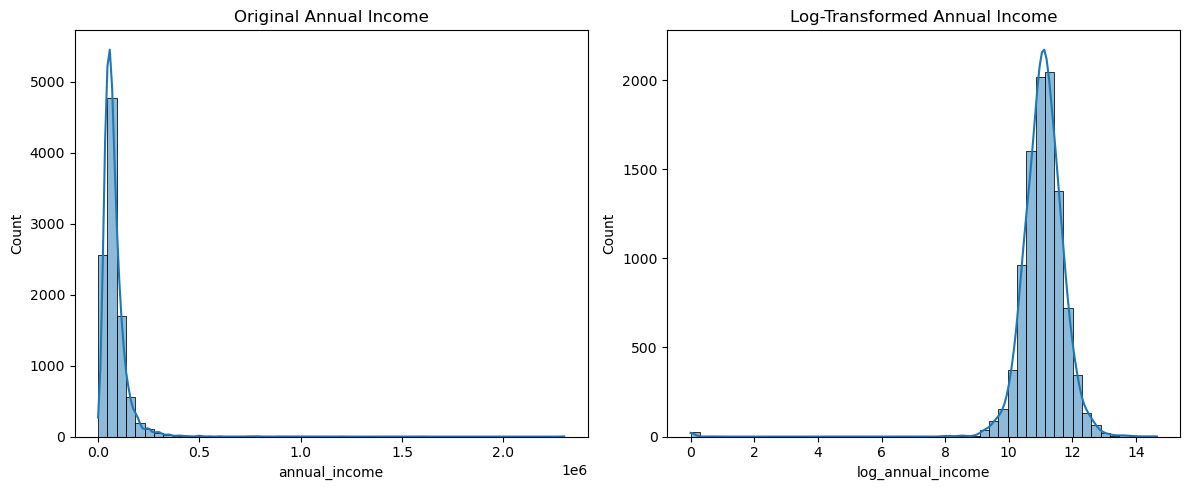

In [48]:
# Plot #1

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
sns.histplot(data_cleaned['annual_income'], bins=50, kde=True)
plt.title('Original Annual Income')

plt.subplot(1, 2, 2)
sns.histplot(data_cleaned['log_annual_income'], bins=50, kde=True)
plt.title('Log-Transformed Annual Income')

plt.tight_layout()
plt.show()


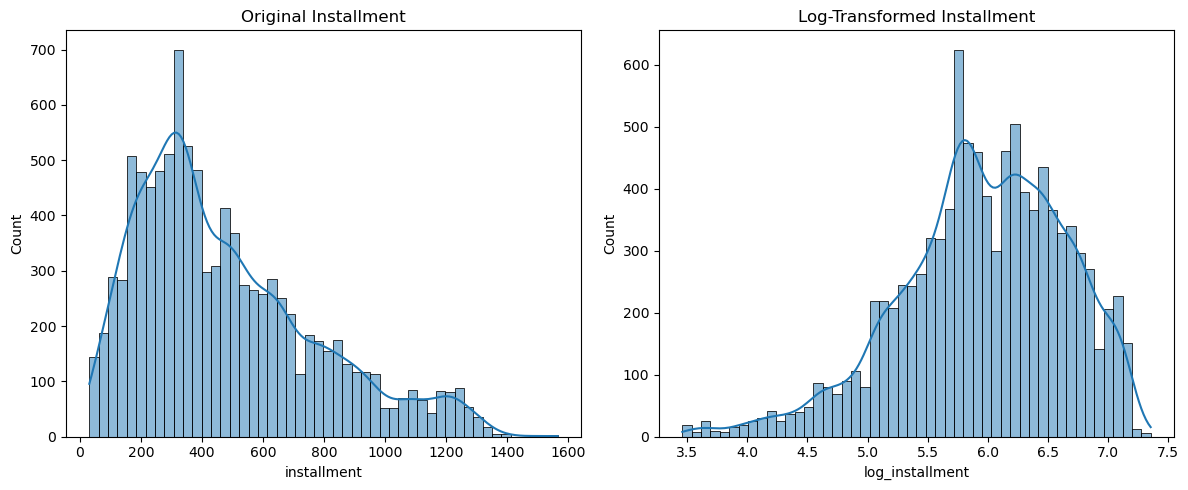

In [50]:
# Plot # 2

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
sns.histplot(data_cleaned['installment'], bins=50, kde=True)
plt.title('Original Installment')

plt.subplot(1, 2, 2)
sns.histplot(data_cleaned['log_installment'], bins=50, kde=True)
plt.title('Log-Transformed Installment')

plt.tight_layout()
plt.show()


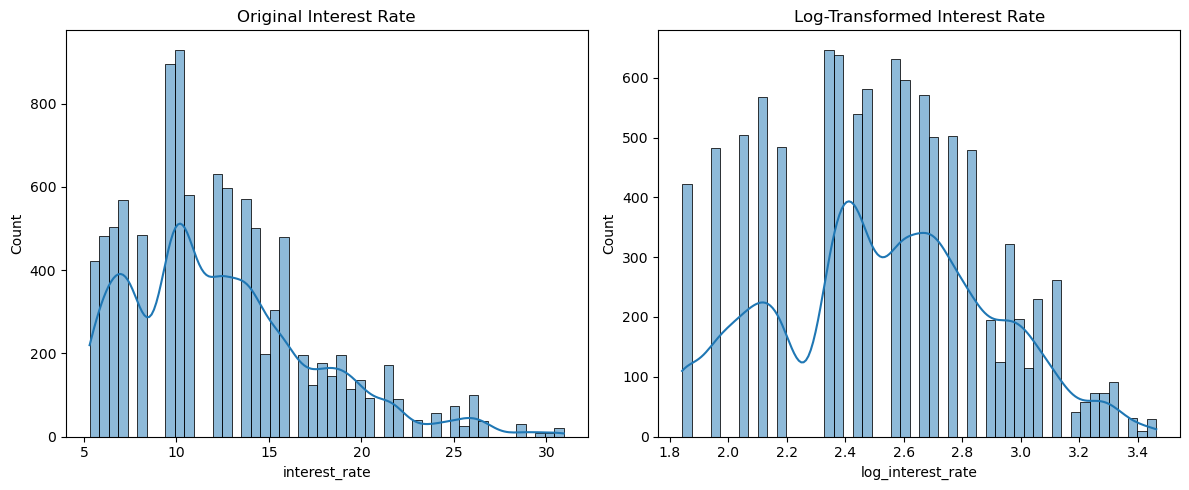

In [52]:
# Plot # 3

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
sns.histplot(data_cleaned['interest_rate'], bins=50, kde=True)
plt.title('Original Interest Rate')

plt.subplot(1, 2, 2)
sns.histplot(data_cleaned['log_interest_rate'], bins=50, kde=True)
plt.title('Log-Transformed Interest Rate')

plt.tight_layout()
plt.show()


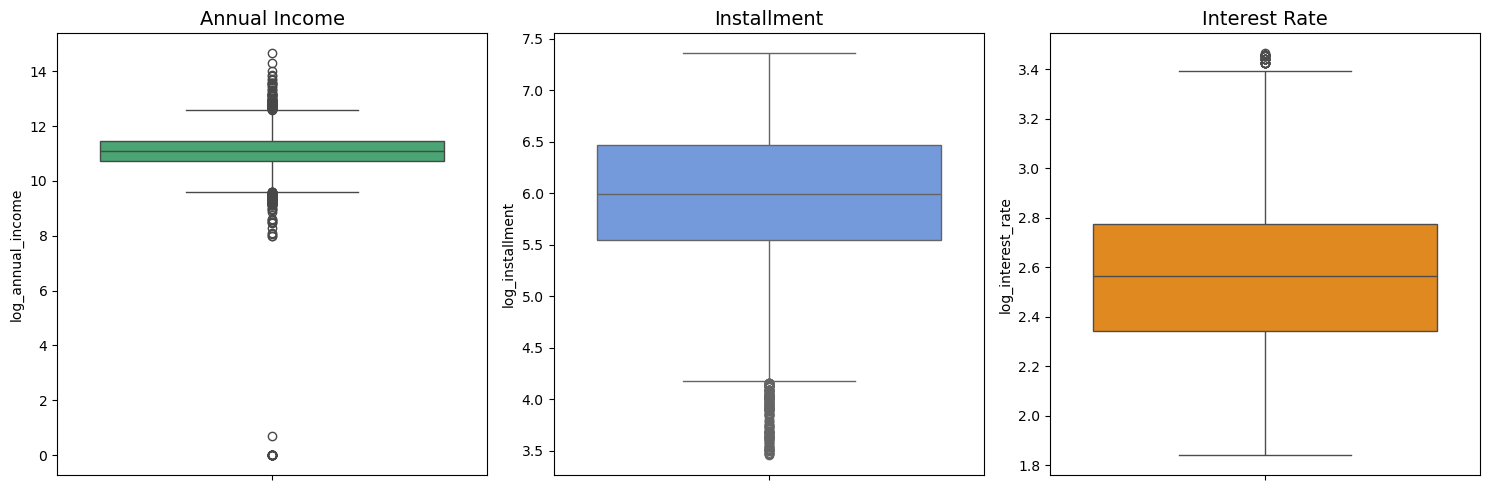

In [54]:
# Cleaned data

plt.figure(figsize=(15, 5))

# Annual income - green
plt.subplot(1, 3, 1)
sns.boxplot(y=data_cleaned['log_annual_income'], color='mediumseagreen')
plt.title('Annual Income', fontsize=14)

# Installment - blue
plt.subplot(1, 3, 2)
sns.boxplot(y=data_cleaned['log_installment'], color='cornflowerblue')
plt.title('Installment', fontsize=14)

# Interest rate - orange
plt.subplot(1, 3, 3)
sns.boxplot(y=data_cleaned['log_interest_rate'], color='darkorange')
plt.title('Interest Rate', fontsize=14)

plt.tight_layout()
plt.show()


In [56]:
data_cleaned['loan_status'].value_counts()

loan_status
Current               9375
Fully Paid             447
In Grace Period         67
Late (31-120 days)      66
Late (16-30 days)       38
Charged Off              7
Name: count, dtype: int64

In [58]:
# Create a function to define a new column risk category based on the loan_status that will be used as Y output parameter in the model:

def map_risk(status):
    if status in ['Current']:
        return 'Low'
    elif status in ['Late (16-30 days)', 'In Grace Period']:
        return 'Medium'
    elif status in ['Charged Off', 'Late (31-120 days)']:
        return 'High'
    else:
        return 'Unknown'

data_cleaned['risk_category'] = data_cleaned['loan_status'].apply(map_risk)

In [62]:
data_cleaned['risk_category'].value_counts()

risk_category
Low        9375
Unknown     447
Medium      105
High         73
Name: count, dtype: int64

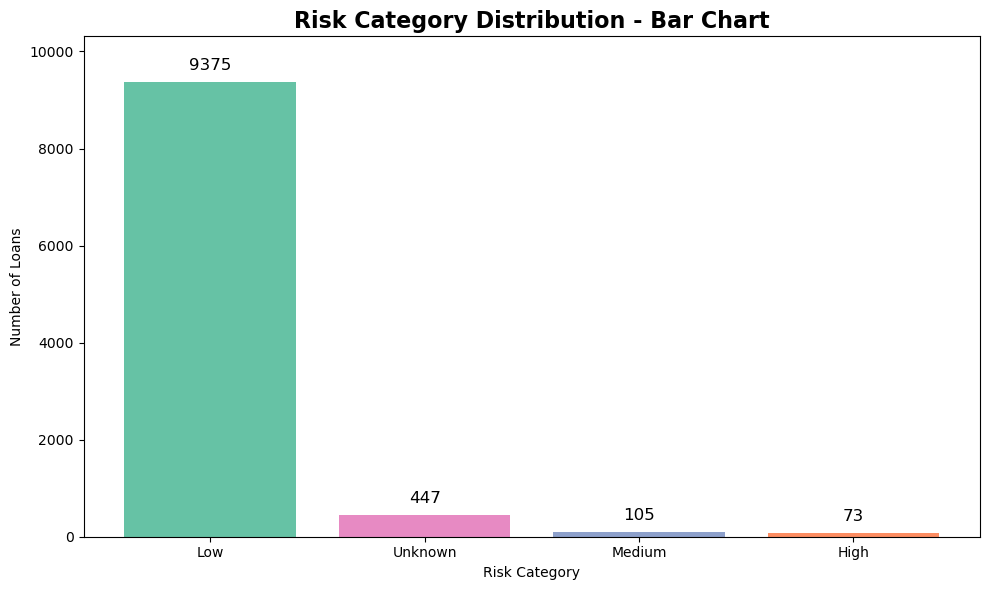

In [64]:

# Count occurrences
risk_counts = data_cleaned['risk_category'].value_counts()
risk_counts = risk_counts.sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(
    risk_counts.index,
    risk_counts.values,
    color=['#66c2a5', '#e78ac3', '#8da0cb', '#fc8d62']
)

# Annotate values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + max(risk_counts.values) * 0.02,  # offset above the bar
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=12
    )

# Add headroom above tallest bar
plt.ylim(0, max(risk_counts.values) * 1.10)

plt.title("Risk Category Distribution - Bar Chart", fontsize=16, weight='bold')
plt.ylabel("Number of Loans")
plt.xlabel("Risk Category")
plt.tight_layout()
plt.show()


#### ------------------------------------------------------------------------------------------------------------------------------------
#### NOTE: Above BAR chart shows Highly Imbalanced data. Data Resampling will be required during Modeling stage to remove imbalance.
#### ------------------------------------------------------------------------------------------------------------------------------------


In [82]:
# List of columns to convert to 'category' dtype
categorical_columns = [
    'emp_length','grade', 'sub_grade', 'homeownership', 'verified_income',
    'state', 'loan_purpose', 'application_type', 'loan_status',
    'initial_listing_status', 'disbursement_method', 'issue_month'
]

# Convert object columns to category type
for col in categorical_columns:
    if col in data_cleaned.columns:
        data_cleaned[col] = data_cleaned[col].astype('category')

# Optional: check the result
print(data_cleaned[categorical_columns].dtypes)


emp_length                category
grade                     category
sub_grade                 category
homeownership             category
verified_income           category
state                     category
loan_purpose              category
application_type          category
loan_status               category
initial_listing_status    category
disbursement_method       category
issue_month               category
dtype: object


In [84]:
#-------------------------
# Encoding Function
#-------------------------


def encode_features(data, one_hot_cols=None, label_encode_cols=None):
    """
    Encodes categorical features using one-hot and label encoding.

    Parameters:
    - data: DataFrame to encode
    - one_hot_cols: List of columns to one-hot encode (default None)
    - label_encode_cols: List of columns to label encode (default None)

    Returns:
    - Encoded DataFrame
    """
    df = data.copy()

    # Step 1: One-hot encode
    if one_hot_cols:
        df = pd.get_dummies(df, columns=one_hot_cols, drop_first=True)

    # Step 2: Convert bool columns to int
    bool_columns = df.select_dtypes(include='bool').columns
    df[bool_columns] = df[bool_columns].astype(int)

    # Step 3: Label encode
    if label_encode_cols:
        for col in label_encode_cols:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))

    return df

# Usage

# one hot encode columns
one_hot_cols = [
    'state', 'homeownership', 'verified_income', 'loan_purpose',
    'application_type', 'grade', 'sub_grade', 'issue_month',
    'loan_status', 'initial_listing_status', 'disbursement_method'
]

label_encode_cols =['emp_length', 'emp_title_clean']

# Run encoding
data_encoded = encode_features(data_cleaned, one_hot_cols, label_encode_cols)


In [86]:
data_encoded.head()

,emp_length,annual_income,debt_to_income,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_limit,...,sub_grade_G4,issue_month_Jan-2018,issue_month_Mar-2018,loan_status_Current,loan_status_Fully Paid,loan_status_In Grace Period,loan_status_Late (16-30 days),loan_status_Late (31-120 days),initial_listing_status_whole,disbursement_method_DirectPay
0,4,90000.0,18.01,0,38.0,2001,6,28,10,70795,...,0,0,1,1,0,0,0,0,1,0
1,2,40000.0,5.04,0,-1.0,1996,1,30,14,28800,...,0,0,0,1,0,0,0,0,1,0
2,4,40000.0,21.15,0,28.0,2006,4,31,10,24193,...,0,0,0,1,0,0,0,0,0,0
3,1,30000.0,10.16,0,-1.0,2007,0,4,4,25400,...,0,1,0,1,0,0,0,0,1,0
4,2,35000.0,57.96,0,-1.0,2008,7,22,16,69839,...,0,0,1,1,0,0,0,0,1,0


In [88]:
data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 164 entries, emp_length to disbursement_method_DirectPay
dtypes: float64(22), int64(141), object(1)
memory usage: 12.5+ MB


In [90]:
## Standard Scalar

# Select numeric columns (excluding target and encoded categoricals)
numeric_cols = data_encoded.select_dtypes(include=['float64', 'int64']).columns
numeric_cols = [col for col in numeric_cols if col not in ['loan_status_Current','loan_status_Fully Paid', 'loan_status_Late (16-30 days)','loan_status_Late (31-120 days)']]  # exclude target

# Scale them
scaler = StandardScaler()
data_encoded[numeric_cols] = scaler.fit_transform(data_encoded[numeric_cols])


In [92]:
# Define leakage columns
leakage_cols = [
    'loan_status_Current',
    'loan_status_Fully Paid',
    'loan_status_In Grace Period',
    'loan_status_Late (16-30 days)',
    'loan_status_Late (31-120 days)'
]

# Drop them safely from data_encoded
data_encoded = data_encoded.drop(columns=leakage_cols, errors='ignore')
data_encoded.shape

(10000, 159)

## 4. Modeling

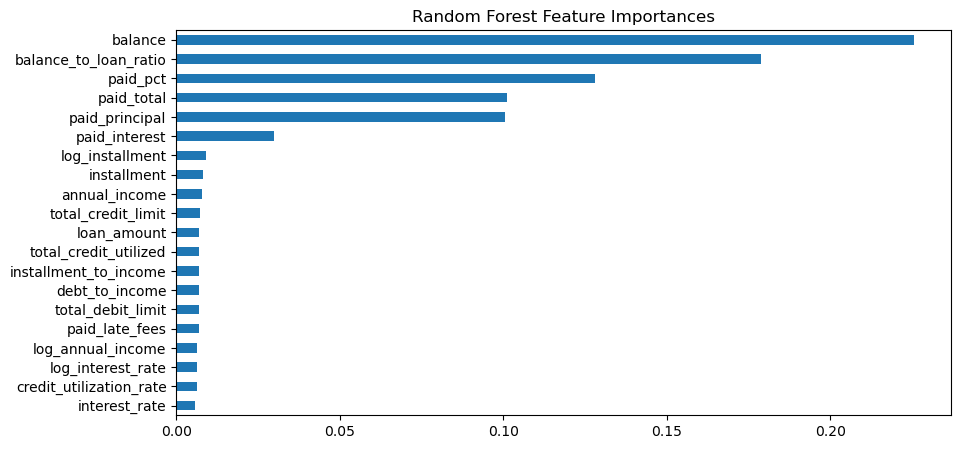

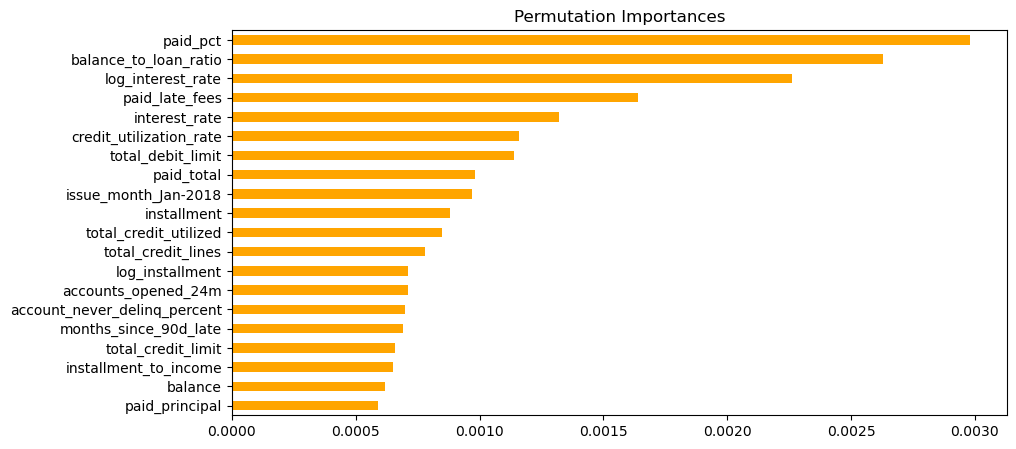

(balance                             0.225743
 balance_to_loan_ratio               0.178954
 paid_pct                            0.128018
 paid_total                          0.100978
 paid_principal                      0.100646
 paid_interest                       0.029996
 log_installment                     0.009089
 installment                         0.008224
 annual_income                       0.007709
 total_credit_limit                  0.007277
 loan_amount                         0.007058
 total_credit_utilized               0.007046
 installment_to_income               0.007032
 debt_to_income                      0.006901
 total_debit_limit                   0.006799
 paid_late_fees                      0.006783
 log_annual_income                   0.006412
 log_interest_rate                   0.006283
 credit_utilization_rate             0.006275
 interest_rate                       0.005774
 total_credit_lines                  0.005690
 num_satisfactory_accounts        

In [2425]:
#--------------------------------------------------------------------------------------
# Feature Importance Function - Find most important featues that drives risk category
#--------------------------------------------------------------------------------------
def feature_importance_analysis(data):

    # Copy data
    data_model = data.copy()

    # Encode categorical columns
    cat_cols = data_model.select_dtypes(include=['object']).columns.tolist()
    if 'risk_category' in cat_cols:
        cat_cols.remove('risk_category')

    le = LabelEncoder()
    for col in cat_cols:
        data_model[col] = le.fit_transform(data_model[col].astype(str))

    # Encode target
    data_model['risk_category_encoded'] = le.fit_transform(data_model['risk_category'])

    drop_cols = ['risk_category', 'risk_category_encoded', 'loan_status', 'emp_title_clean']
    X = data_model.drop(columns=drop_cols, errors='ignore')
    y = data_model['risk_category_encoded']

    # Fit RF
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X, y)

    # Feature importances
    importances = pd.Series(model.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=False)

    # Plot

    plt.figure(figsize=(10,5))
    importances.head(20).plot(kind='barh')
    plt.title('Random Forest Feature Importances')
    plt.gca().invert_yaxis()
    plt.show()

    # Permutation importance
    result = permutation_importance(model, X, y, n_repeats=10, random_state=42)
    perm_importances = pd.Series(result.importances_mean, index=X.columns)
    perm_importances = perm_importances.sort_values(ascending=False)

    # Plot
    plt.figure(figsize=(10,5))
    perm_importances.head(20).plot(kind='barh', color='orange')
    plt.title('Permutation Importances')
    plt.gca().invert_yaxis()
    plt.show()

    return importances, perm_importances

feature_importance_analysis(data_encoded)

In [80]:
# 1 — Selected Top 41 Features ONLY based on the feature importance

top_features = [
    'balance',
    'balance_to_loan_ratio',
    'paid_pct',
    'paid_total',
    'paid_principal',
    'paid_interest',
    'log_installment',
    'installment',
    'annual_income',
    'total_credit_limit',
    'loan_amount',
    'total_credit_utilized',
    'installment_to_income',
    'debt_to_income',
    'total_debit_limit',
    'paid_late_fees',
    'log_annual_income',
    'log_interest_rate',
    'credit_utilization_rate',
    'interest_rate',
    'total_credit_lines',
    'num_satisfactory_accounts',
    'open_credit_lines',
    'months_since_last_credit_inquiry',
    'num_cc_carrying_balance',
    'num_total_cc_accounts',
    'inquiries_last_12m',
    'credit_history_length',
    'num_open_cc_accounts',
    'earliest_credit_line',
    'accounts_opened_24m',
    'num_active_debit_accounts',
    'account_never_delinq_percent',
    'emp_length',
    'months_since_last_delinq',
    'months_since_90d_late',
    'current_installment_accounts',
    'issue_month_Jan-2018',
    'num_mort_accounts',
    'term'
]


Original class distribution:
risk_category
Low       9375
Medium     105
High        73
Name: count, dtype: int64

Class distribution in y_train BEFORE SMOTE:
risk_category
Low       6562
Medium      74
High        51
Name: count, dtype: int64

Class distribution in y_test:
risk_category
Low       2813
Medium      31
High        22
Name: count, dtype: int64

Class distribution AFTER SMOTE:
risk_category
Low       6562
High      6562
Medium    6562
Name: count, dtype: int64

Classification Report:

              precision    recall  f1-score   support

        High       0.92      0.55      0.69        22
         Low       0.99      1.00      0.99      2813
      Medium       0.00      0.00      0.00        31

    accuracy                           0.98      2866
   macro avg       0.64      0.51      0.56      2866
weighted avg       0.97      0.98      0.98      2866



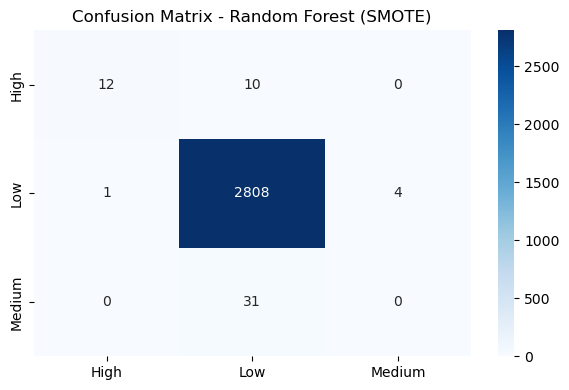

In [2433]:
# -------------------------------------------------------------------------------------------
# Baseline Model #1 — Random Forest (with SMOTE - Synthetic Minority Over-sampling Technique
# -------------------------------------------------------------------------------------------

# 2 — Prepare Data

# Filter out rows where risk_category == "Unknown"
data_filtered = data_encoded[data_encoded['risk_category'] != 'Unknown'].copy()

X = data_filtered[top_features]
y = data_filtered['risk_category']

print("Original class distribution:")
print(y.value_counts())


# 3 — Split Data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

print("\nClass distribution in y_train BEFORE SMOTE:")
print(y_train.value_counts())

print("\nClass distribution in y_test:")
print(y_test.value_counts())


# 4 — Apply SMOTE Only On Training Data

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\nClass distribution AFTER SMOTE:")
print(y_train_balanced.value_counts())


# 5 — Train Random Forest

model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train_balanced, y_train_balanced)


# 6 — Predict On Test Data


y_pred = model.predict(X_test)


# 7 — Evaluate Model


# Create consistent list of known labels
known_labels = sorted(y_train_balanced.unique())

print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    labels=known_labels,
    zero_division=0
))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=known_labels)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=known_labels,
    yticklabels=known_labels
)

plt.title("Confusion Matrix - Random Forest (SMOTE)")
plt.tight_layout()
plt.show()


#### -----------------------------------------------------------------------------------------------------------------------
### Baselie Model # 1 : Random Forest Summary (SMOTE - Synthetic Minority Over-sampling Technique)
#### -----------------------------------------------------------------------------------------------------------------------


| Class            | Precision | Recall | F1-Score | Support | Description                                                       |
|------------------|-----------|--------|----------|---------|-------------------------------------------------------------------|
| High             | 0.92      | 0.55   | 0.69     | 22      | Excellent precision, but recall is moderate. Model finds many true positives but still misses some. |
| Low              | 0.99      | 1.00   | 0.99     | 2813    | Near-perfect performance. Model almost perfectly identifies Low risk loans. |
| Medium           | 0.00      | 0.00   | 0.00     | 31      | Model completely fails to detect Medium class; all predictions are incorrect. |
| **Accuracy**     |           |        | 0.98     | 2866    | Overall very high accuracy, driven mostly by the Low class’s dominance. |
| **Macro avg**    | 0.64      | 0.51   | 0.56     | 2866    | Averages across classes; dragged down heavily by Medium’s poor performance. |
| **Weighted avg** | 0.97      | 0.98   | 0.98     | 2866    | High because the Low class dominates the data, masking other weaknesses. |


#### Summary:
- The model achieves excellent performance on the Low-risk category, with near-perfect precision and recall. 
- However, it struggles to identify Medium-risk loans entirely, achieving zero recall and F1-score for this class, likely due to severe class imbalance.
- High-risk loans show decent precision (0.92) but lower recall (0.55), indicating that some High-risk cases remain undetected.
- The overall accuracy is very high at 98%, but macro-averaged metrics reveal the impact of the model’s difficulty handling minority classes.

Class distribution BEFORE SMOTE:
risk_category
Low       6562
Medium      74
High        51
Name: count, dtype: int64

Class distribution AFTER SMOTE:
risk_category
Low       6562
High      6562
Medium    6562
Name: count, dtype: int64


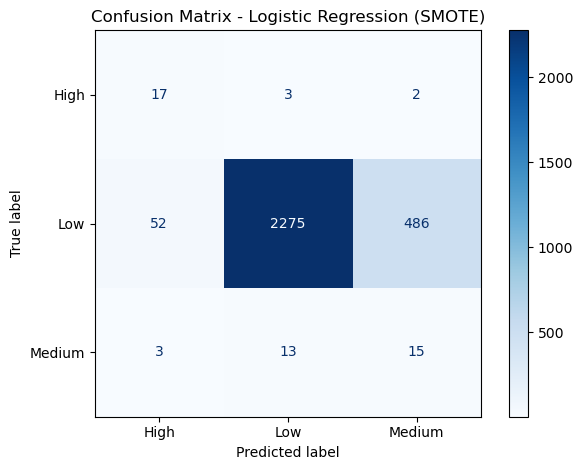


Classification Report:
              precision    recall  f1-score   support

        High       0.24      0.77      0.36        22
         Low       0.99      0.81      0.89      2813
      Medium       0.03      0.48      0.06        31

    accuracy                           0.80      2866
   macro avg       0.42      0.69      0.44      2866
weighted avg       0.98      0.80      0.88      2866



In [94]:
# ---------------------------------------------------------------------------------------------
# Baseline Model # 2 : Logistic Regression (SMOTE - Synthetic Minority Over-sampling Technique)
# ---------------------------------------------------------------------------------------------


# 2 — Remove Unknown rows

# Filter out Unknown rows from the dataset
data_filtered = data_encoded[data_encoded['risk_category'] != 'Unknown']


# 3 — Subset Dataset


X = data_filtered[top_features]
y = data_filtered['risk_category']


# 4 — Split Data (before SMOTE!)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Class distribution BEFORE SMOTE:")
print(y_train.value_counts())


# 5 — Apply SMOTE ONLY on *** TRAINING DATA ***


smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\nClass distribution AFTER SMOTE:")
print(y_train_balanced.value_counts())

# 6 — Train Logistic Regression


model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='liblinear'
)

model.fit(X_train_balanced, y_train_balanced)


# 7 — Predict on Test Set


y_pred = model.predict(X_test)


# 8 — Evaluate
# ------------------------------------------

# Confusion Matrix
labels = ['High', 'Low', 'Medium']

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    labels=labels,
    cmap='Blues',
    values_format='d'
)

plt.title("Confusion Matrix - Logistic Regression (SMOTE)")
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    labels=labels,
    zero_division=0
))


#### ---------------------------------------------------------------------------------------------------------------------
### Baseline Model # 2  Logistic Regression Summary (SMOTE - Synthetic Minority Over-sampling Technique)
#### ---------------------------------------------------------------------------------------------------------------------

| Class          | Precision | Recall | F1-Score | Support | Summary Description                                                  |
|----------------|-----------|--------|----------|---------|----------------------------------------------------------------------|
| High           | 0.24      | 0.77   | 0.36     | 22      | Recall is decent, but precision is extremely low. Many false positives. |
| Low            | 0.99      | 0.81   | 0.89     | 2813    | Very strong performance; high precision and recall. Drives overall accuracy. |
| Medium         | 0.03      | 0.48   | 0.06     | 31      | Serious problems detecting Medium class; poor precision and recall.   |
| **Accuracy**   |           |        | 0.80     | 2866    | Overall model accuracy is moderate but driven by Low class dominance. |
| **Macro avg**  | 0.42      | 0.69   | 0.44     | 2866    | Reflects class imbalance; Medium drags averages down.                 |
| **Weighted avg**| 0.98     | 0.80   | 0.88     | 2866    | High due to Low class’s dominance despite other classes performing poorly. |


#### Summary:
- The Logistic Regression model with SMOTE shows strong performance for the Low-risk category, achieving very high precision (0.99) and a solid F1-score (0.89).
- For the High-risk class, recall is good(0.77), meaning the model successfully detects most High-risk loans. However, precision is low (0.24), indicating a high number of false positives.
- The Medium-risk category remains highly problematic, with very poor precision (0.03) and an almost negligible F1-score (0.06), suggesting the model struggles to distinguish Medium-risk loans despite SMOTE balancing.
- Overall accuracy is reasonable at 80%, but macro-averaged metrics reflect the challenge of achieving balanced performance across all classes.

Class mapping: {'High': 0, 'Low': 1, 'Medium': 2}
Class distribution BEFORE SMOTE:
1    6562
2      74
0      51
Name: count, dtype: int64

Class distribution AFTER SMOTE:
1    6562
0    6562
2    6562
Name: count, dtype: int64
Numeric class weights: {1: 1.0, 2: 10.0, 0: 15.0}


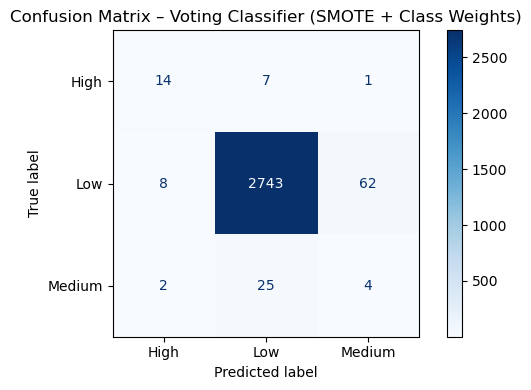


Classification Report:

              precision    recall  f1-score   support

        High       0.58      0.64      0.61        22
         Low       0.99      0.98      0.98      2813
      Medium       0.06      0.13      0.08        31

    accuracy                           0.96      2866
   macro avg       0.54      0.58      0.56      2866
weighted avg       0.98      0.96      0.97      2866


Overall Accuracy: 0.9634


In [2446]:
# ----------------------------------------------------------------
# Voting Classifier with Feature Selection + SMOTE + Class Weights
# ----------------------------------------------------------------

# 2 — Prepare Data


# Remove Unknown rows
data_filtered = data_encoded[data_encoded['risk_category'] != 'Unknown']

# Define X and y
X = data_filtered[top_features]
y = data_filtered['risk_category']

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Check mapping
class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Class mapping:", class_mapping)

# 3 — Split Data BEFORE SMOTE

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.3,
    random_state=42,
    stratify=y_encoded
)

print("Class distribution BEFORE SMOTE:")
print(pd.Series(y_train).value_counts())


# 4 — Apply SMOTE on Training Data Only

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\nClass distribution AFTER SMOTE:")
print(pd.Series(y_train_balanced).value_counts())


# 5 — Define Class Weights

class_weight = {
    class_mapping['Low']: 1.0,
    class_mapping['Medium']: 10.0,
    class_mapping['High']: 15.0
}

print("Numeric class weights:", class_weight)


# 6 — Define Base Models

log_clf = LogisticRegression(
    max_iter=1000,
    class_weight=class_weight,
    solver='liblinear',
    random_state=42
)

rf_clf = RandomForestClassifier(
    class_weight=class_weight,
    random_state=42
)

svc_clf = SVC(
    probability=True,
    class_weight=class_weight,
    random_state=42
)

dt_clf = DecisionTreeClassifier(
    class_weight=class_weight,
    random_state=42
)

gb_clf = GradientBoostingClassifier(random_state=42)
ada_clf = AdaBoostClassifier(random_state=42)


# 7 — Fit Boosting Models Separately

sample_weights_train = pd.Series(y_train_balanced).map(class_weight).values

gb_clf.fit(X_train_balanced, y_train_balanced, sample_weight=sample_weights_train)
ada_clf.fit(X_train_balanced, y_train_balanced, sample_weight=sample_weights_train)


# 8 — Voting Classifier WITHOUT KNN


voting_clf = VotingClassifier(
    estimators=[
        ('lr', log_clf),
        ('rf', rf_clf),
        ('svc', svc_clf),
        ('dt', dt_clf),
        ('gb', gb_clf),
        ('ada', ada_clf)
    ],
    voting='soft'
)

# Fit Voting Classifier
voting_clf.fit(X_train_balanced, y_train_balanced, sample_weight=sample_weights_train)


# 9 — Evaluate on Test Data

y_pred_encoded = voting_clf.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)
y_test_labels = le.inverse_transform(y_test)

# Confusion Matrix
labels = le.classes_
cm = confusion_matrix(y_test_labels, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig = disp.plot(cmap='Blues', values_format='d')
fig.ax_.set_title("Confusion Matrix – Voting Classifier (SMOTE + Class Weights)")
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(
    y_test_labels,
    y_pred,
    labels=labels,
    zero_division=0
))

# Overall Accuracy
acc = accuracy_score(y_test_labels, y_pred)
print(f"\nOverall Accuracy: {acc:.4f}")


In [2448]:

# --------------------------------------------------------
# Compare Models — Voting Classifier Ensemble Members
# --------------------------------------------------------


# Define models again 
models = [
    ('Logistic Regression', log_clf),
    ('Random Forest', rf_clf),
    ('SVC', svc_clf),
    ('Decision Tree', dt_clf),
    ('Gradient Boosting', gb_clf),
    ('AdaBoost', ada_clf)
]

# Loop through each model
for name, model in models:
    print(f"\n==============================")
    print(f"Model: {name}")
    print(f"==============================")
    
    # Check if model supports sample_weight
    if name in ['Gradient Boosting', 'AdaBoost']:
        model.fit(
            X_train_balanced,
            y_train_balanced,
            sample_weight=sample_weights_train
        )
    else:
        model.fit(X_train_balanced, y_train_balanced)
    
    # Predict on test set
    y_pred_encoded = model.predict(X_test)
    
    # Inverse-transform predictions and true labels
    y_pred = le.inverse_transform(y_pred_encoded)
    y_test_labels = le.inverse_transform(y_test)
    
    # Accuracy
    acc = accuracy_score(y_test_labels, y_pred)
    print(f"Accuracy: {acc:.4f}")
    
    # Classification Report
    print(classification_report(
        y_test_labels,
        y_pred,
        target_names=le.classes_,
        zero_division=0
    ))



Model: Logistic Regression
Accuracy: 0.4972
              precision    recall  f1-score   support

        High       0.23      0.82      0.36        22
         Low       1.00      0.49      0.66      2813
      Medium       0.02      0.77      0.03        31

    accuracy                           0.50      2866
   macro avg       0.41      0.69      0.35      2866
weighted avg       0.98      0.50      0.65      2866


Model: Random Forest
Accuracy: 0.9819
              precision    recall  f1-score   support

        High       0.67      0.36      0.47        22
         Low       0.98      1.00      0.99      2813
      Medium       0.00      0.00      0.00        31

    accuracy                           0.98      2866
   macro avg       0.55      0.45      0.49      2866
weighted avg       0.97      0.98      0.98      2866


Model: SVC
Accuracy: 0.9637
              precision    recall  f1-score   support

        High       0.76      0.59      0.67        22
         Low    

#### ----------------------------------------------------------------------------------------------
### Voting Classifier (SMOTE + Class Weights): Comparison Summary
#### -----------------------------------------------------------------------------------------------

| Class   | Precision | Recall | F1-Score | Support | Summary Description |
|---------|-----------|--------|----------|---------|---------------------|
| High    | 0.58      | 0.64   | 0.61     | 22      | Good precision and moderate recall, indicating the model is identifying many high-risk cases but still missing some. |
| Low     | 0.99      | 0.98   | 0.98     | 2813    | Excellent performance; the model predicts Low risk with very high confidence and completeness. |
| Medium  | 0.06      | 0.13   | 0.08     | 31      | Very poor precision and recall; the model struggles significantly to detect Medium risk cases. |
| **Overall Accuracy** |        |        | **0.96** | 2866    | High overall accuracy, driven mainly by excellent Low class performance, but Medium class detection remains weak. |
| Macro Avg | 0.54    | 0.58   | 0.56     |         | Reflects imbalance: high Low-class performance overshadows poor Medium-class results, dragging macro averages down. |
| Weighted Avg | 0.98 | 0.96   | 0.97     |         | High weighted averages thanks to dominant Low class; these metrics are less meaningful in presence of class imbalance. |


### Highlights & Takeaways
- Low Class: Stellar metrics across the board. The model easily picks out Low-risk observations.
- High Class: Fairly decent precision and recall (~60%), but some misclassification remains.
- Medium Class: Practically undetectable. Precision and recall both very low, meaning the model rarely correctly identifies Medium cases.This significantly limits usefulness if Medium risk is clinically or financially important.

### Next Steps & Imbalance Improvements: 

- Adjust class weights further to penalize Medium misclassification more heavily.
- Try ensemble methods specifically optimized for minority classes (e.g. Balanced Random Forest).
- Re-tune SMOTE parameters for more realistic synthetic samples.
- Explore alternative sampling methods like SMOTE-ENN or Tomek Links.
- Feature engineering: Are there unique predictors differentiating Medium from Low/High?
